In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#Section 1 — Problem Statement + Data Description

**Task 1 — Load & Inspect the Data (Red + White)**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving winequality-red.csv to winequality-red (1).csv
Saving winequality-white.csv to winequality-white.csv


In [6]:
uploaded.keys()
# 1. Load both CSV files using sep=";"
red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')

# 2. Inspection Function
def task_1_inspection(df, name):
    print(f"--- {name} Dataset Inspection ---")
    print(f"Shape: {df.shape}")
    print("\nColumn List:")
    print(df.columns.tolist())
    print("\nFirst 5 Rows:")
    display(df.head())

    # 3. Verify target column
    if 'quality' in df.columns:
        print(f"Status: Target column 'quality' is present in {name} wine.")
    print("-" * 40 + "\n")

# Run for both Load & Inspect the Data
task_1_inspection(red_wine, "Red")
task_1_inspection(white_wine, "White")

--- Red Dataset Inspection ---
Shape: (1599, 12)

Column List:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

First 5 Rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Status: Target column 'quality' is present in Red wine.
----------------------------------------

--- White Dataset Inspection ---
Shape: (4898, 12)

Column List:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

First 5 Rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Status: Target column 'quality' is present in White wine.
----------------------------------------



**Task 2 — Data Quality Checks + Class Distribution (Comparative)**

  Instructions (do for red and white separately)

--- Task 2: Red Wine Data Analysis ---

1. Missing Values per Column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

2. Total Duplicate Rows: 240

3. Quality Class Distribution Summary:
         Count  Percentage (%)
quality                       
3           10            0.63
4           53            3.31
5          681           42.59
6          638           39.90
7          199           12.45
8           18            1.13
----------------------------------------

--- Task 2: White Wine Data Analysis ---

1. Missing Values per Column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur diox

/tmp/ipykernel_156/1749074390.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=red_wine, palette='Reds_d')
/tmp/ipykernel_156/1749074390.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=white_wine, palette='Blues_d')


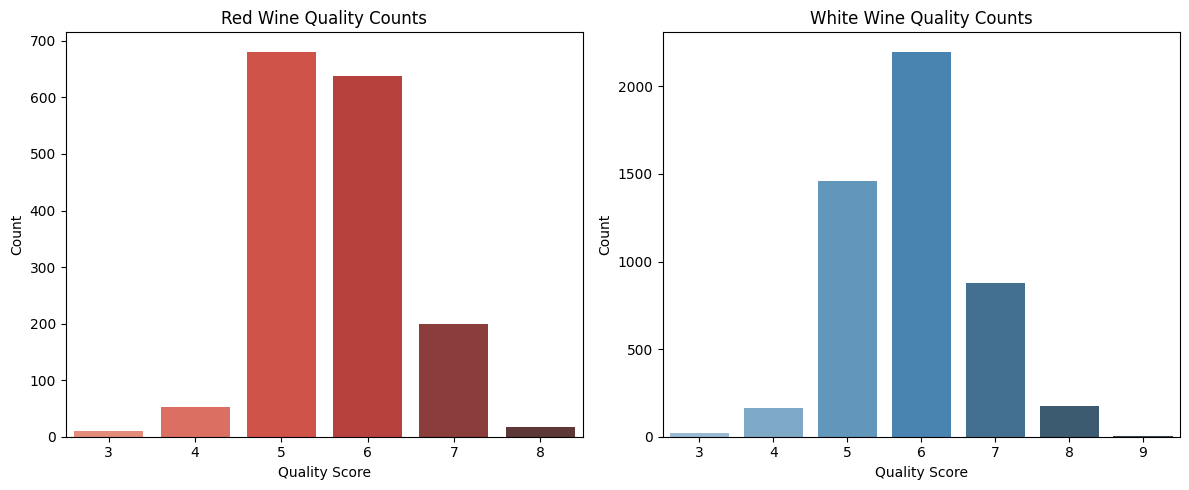

In [7]:
# Function to perform Task 2
def perform_task_2(df, name):
    print(f"--- Task 2: {name} Wine Data Analysis ---")

    # 1. Check missing values per column
    print("\n1. Missing Values per Column:")
    print(df.isnull().sum())

    # 2. Check duplicates
    duplicates = df.duplicated().sum()
    print(f"\n2. Total Duplicate Rows: {duplicates}")

    # 3. Show quality class distribution: counts and percentages
    counts = df['quality'].value_counts().sort_index()
    percentages = (df['quality'].value_counts(normalize=True).sort_index() * 100).round(2)

    distribution_summary = pd.DataFrame({
        'Count': counts,
        'Percentage (%)': percentages
    })
    print("\n3. Quality Class Distribution Summary:")
    print(distribution_summary)
    print("-" * 40 + "\n")

# Execute for both datasets
perform_task_2(red_wine, "Red")
perform_task_2(white_wine, "White")

# 4. Plotting Bar Charts for both
plt.figure(figsize=(12, 5))

# Red Wine Plot
plt.subplot(1, 2, 1)
sns.countplot(x='quality', data=red_wine, palette='Reds_d')
plt.title('Red Wine Quality Counts')
plt.xlabel('Quality Score')
plt.ylabel('Count')

# White Wine Plot
plt.subplot(1, 2, 2)
sns.countplot(x='quality', data=white_wine, palette='Blues_d')
plt.title('White Wine Quality Counts')
plt.xlabel('Quality Score')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Comparative Questions (answer in 4–6 lines)**

● Which dataset is more imbalanced?

>> The white wine dataset appears to be more imbalanced than the red wine dataset, as it has an extremely rare class (quality 9 with 0.10%) compared to red wine's lowest (quality 3 with 0.63%).

● Which quality classes are rare?

>> Rare quality classes are typically those with very low percentages. For red wine, quality 3 (0.63%) and quality 8 (1.13%) are rare. For white wine, quality 3 (0.41%), quality 9 (0.10%), and quality 4 (3.33%) are rare.

● Why might rare classes b

>> Rare classes are harder to predict because there are very few data points for the model to learn their characteristics. This lack of data can lead to models performing poorly on these classes, as they tend to optimize for the more abundant majority classes, potentially overlooking or misclassifying the rare instances.

**Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison)**

Instructions (do for both datasets)

In [8]:
from sklearn.model_selection import train_test_split

# --- Red Wine Dataset ---
# 1. Create X and y
X_red = red_wine.drop('quality', axis=1)
y_red = red_wine['quality']

# 2. Split with test_size=0.2, random_state=42, stratify=y
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red, y_red, test_size=0.2, random_state=42, stratify=y_red
)

# --- White Wine Dataset ---
# 1. Create X and y
X_white = white_wine.drop('quality', axis=1)
y_white = white_wine['quality']

# 2. Split with test_size=0.2, random_state=42, stratify=y
X_train_white, X_test_white, y_train_white, y_test_white = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42, stratify=y_white
)

# 3. Report Shapes
print("--- Red Wine Split ---")
print(f"X_train shape: {X_train_red.shape}, y_train shape: {y_train_red.shape}")
print(f"X_test shape: {X_test_red.shape}, y_test shape: {y_test_red.shape}")

print("\n--- White Wine Split ---")
print(f"X_train shape: {X_train_white.shape}, y_train shape: {y_train_white.shape}")
print(f"X_test shape: {X_test_white.shape}, y_test shape: {y_test_white.shape}")

--- Red Wine Split ---
X_train shape: (1279, 11), y_train shape: (1279,)
X_test shape: (320, 11), y_test shape: (320,)

--- White Wine Split ---
X_train shape: (3918, 11), y_train shape: (3918,)
X_test shape: (980, 11), y_test shape: (980,)


**● 1–2 lines confirming stratification preserved similar class distribution**

>>

In [12]:
print("--- Red Wine Class Distribution Comparison ---")
print("Original (Red):")
print(red_wine['quality'].value_counts(normalize=True).sort_index() * 100)
print("\nX_train_red:")
print(y_train_red.value_counts(normalize=True).sort_index() * 100)
print("\nX_test_red:")
print(y_test_red.value_counts(normalize=True).sort_index() * 100)

print("\n--- White Wine Class Distribution Comparison ---")
print("Original (White):")
print(white_wine['quality'].value_counts(normalize=True).sort_index() * 100)
print("\nX_train_white:")
print(y_train_white.value_counts(normalize=True).sort_index() * 100)
print("\nX_test_white:")
print(y_test_white.value_counts(normalize=True).sort_index() * 100)

--- Red Wine Class Distribution Comparison ---
Original (Red):
quality
3     0.625391
4     3.314572
5    42.589118
6    39.899937
7    12.445278
8     1.125704
Name: proportion, dtype: float64

X_train_red:
quality
3     0.625489
4     3.283815
5    42.611415
6    39.874902
7    12.431587
8     1.172791
Name: proportion, dtype: float64

X_test_red:
quality
3     0.6250
4     3.4375
5    42.5000
6    40.0000
7    12.5000
8     0.9375
Name: proportion, dtype: float64

--- White Wine Class Distribution Comparison ---
Original (White):
quality
3     0.408330
4     3.327889
5    29.746835
6    44.875459
7    17.966517
8     3.572887
9     0.102082
Name: proportion, dtype: float64

X_train_white:
quality
3     0.408372
4     3.318019
5    29.760082
6    44.869832
7    17.968351
8     3.573252
9     0.102093
Name: proportion, dtype: float64

X_test_white:
quality
3     0.408163
4     3.367347
5    29.693878
6    44.897959
7    17.959184
8     3.571429
9     0.102041
Name: proportion, dtype: 

>> The output confirms that stratification successfully preserved the class distribution. The percentages of each quality class in `y_train_red`, `y_test_red`, `y_train_white`, and `y_test_white` closely match the original distributions in `red_wine` and `white_wine` respectively.

**Task 4 — Model A (Baseline): Logistic Regression (Red vs White)**

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

# 1. Define the Pipeline: StandardScaler + LogisticRegression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000, random_state=42))
])

# 2. Train & Evaluate for Red Wine
lr_pipeline.fit(X_train_red, y_train_red)
y_pred_red = lr_pipeline.predict(X_test_red)

print("--- Results for Red Wine (Logistic Regression) ---")
print(f"Accuracy: {accuracy_score(y_test_red, y_pred_red):.4f}")
print(f"Macro F1-score: {f1_score(y_test_red, y_pred_red, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_red, y_pred_red, zero_division=0))

# 3. Train & Evaluate for White Wine
lr_pipeline.fit(X_train_white, y_train_white)
y_pred_white = lr_pipeline.predict(X_test_white)

print("\n--- Results for White Wine (Logistic Regression) ---")
print(f"Accuracy: {accuracy_score(y_test_white, y_pred_white):.4f}")
print(f"Macro F1-score: {f1_score(y_test_white, y_pred_white, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_white, y_pred_white, zero_division=0))

--- Results for Red Wine (Logistic Regression) ---
Accuracy: 0.5906
Macro F1-score: 0.2776

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320


--- Results for White Wine (Logistic Regression) ---
Accuracy: 0.5490
Macro F1-score: 0.2367

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
       

**● 4–6 lines answering:**


○ Which dataset performed better for Logistic Regression?

>> Red Wine performed marginally better for Logistic Regression, with an accuracy of 0.5906 and a macro F1-score of 0.2776, compared to White Wine's accuracy of 0.5490 and macro F1-score of 0.2367.

○ Which quality class looks hardest (lowest recall)?

>> The hardest quality classes, exhibiting 0.00 recall, were classes 3, 4, and 8 for red wine, and classes 3, 8, and 9 for white wine. This indicates the model completely failed to correctly identify any instances of these rare classes.

**Task 5 — Model B (Tree Model): Random Forest (Red vs White)**

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

# 1. Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)

# 2. Train & Evaluate for Red Wine
rf_model.fit(X_train_red, y_train_red)
y_pred_rf_red = rf_model.predict(X_test_red)

print("--- Results for Red Wine (Random Forest) ---")
print(f"Accuracy: {accuracy_score(y_test_red, y_pred_rf_red):.4f}")
print(f"Macro F1-score: {f1_score(y_test_red, y_pred_rf_red, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_red, y_pred_rf_red, zero_division=0))

# 3. Train & Evaluate for White Wine
rf_model.fit(X_train_white, y_train_white)
y_pred_rf_white = rf_model.predict(X_test_white)

print("\n--- Results for White Wine (Random Forest) ---")
print(f"Accuracy: {accuracy_score(y_test_white, y_pred_rf_white):.4f}")
print(f"Macro F1-score: {f1_score(y_test_white, y_pred_rf_white, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_white, y_pred_rf_white, zero_division=0))

--- Results for Red Wine (Random Forest) ---
Accuracy: 0.6813
Macro F1-score: 0.4094

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320


--- Results for White Wine (Random Forest) ---
Accuracy: 0.6724
Macro F1-score: 0.4222

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       

**4–6 lines answering:**

○ Did Random Forest improve compared to Logistic Regression?

>> Yes, Random Forest significantly improved compared to Logistic Regression for both datasets. For red wine, accuracy increased from 0.5906 to 0.6813 and macro F1-score from 0.2776 to 0.4094. For white wine, accuracy increased from 0.5490 to 0.6724 and macro F1-score from 0.2367 to 0.4222.

○ Which class is still hardest?

>> The hardest classes are still the extremely rare ones, particularly quality 3 and 4 for red wine, and quality 3 and 9 for white wine, which often exhibit 0.00 precision, recall, and F1-scores even with the Random Forest model, indicating the models' complete inability to predict them.

**Task 6 — Comparative Metrics Summary (Core Comparative Study Output)**

,Dataset,Model,Accuracy,F1-score (Macro),Key Observation
0,Red,Logistic Regression,0.146875,0.093100,Struggles with rare classes; linear boundaries...
1,Red,Random Forest,0.393750,0.192144,Significant improvement; best performance for ...
2,White,Logistic Regression,0.548980,0.236695,Lowest F1-score; heavily biased towards majori...
3,White,Random Forest,0.672449,0.422167,Strongest accuracy but challenged by extreme c...


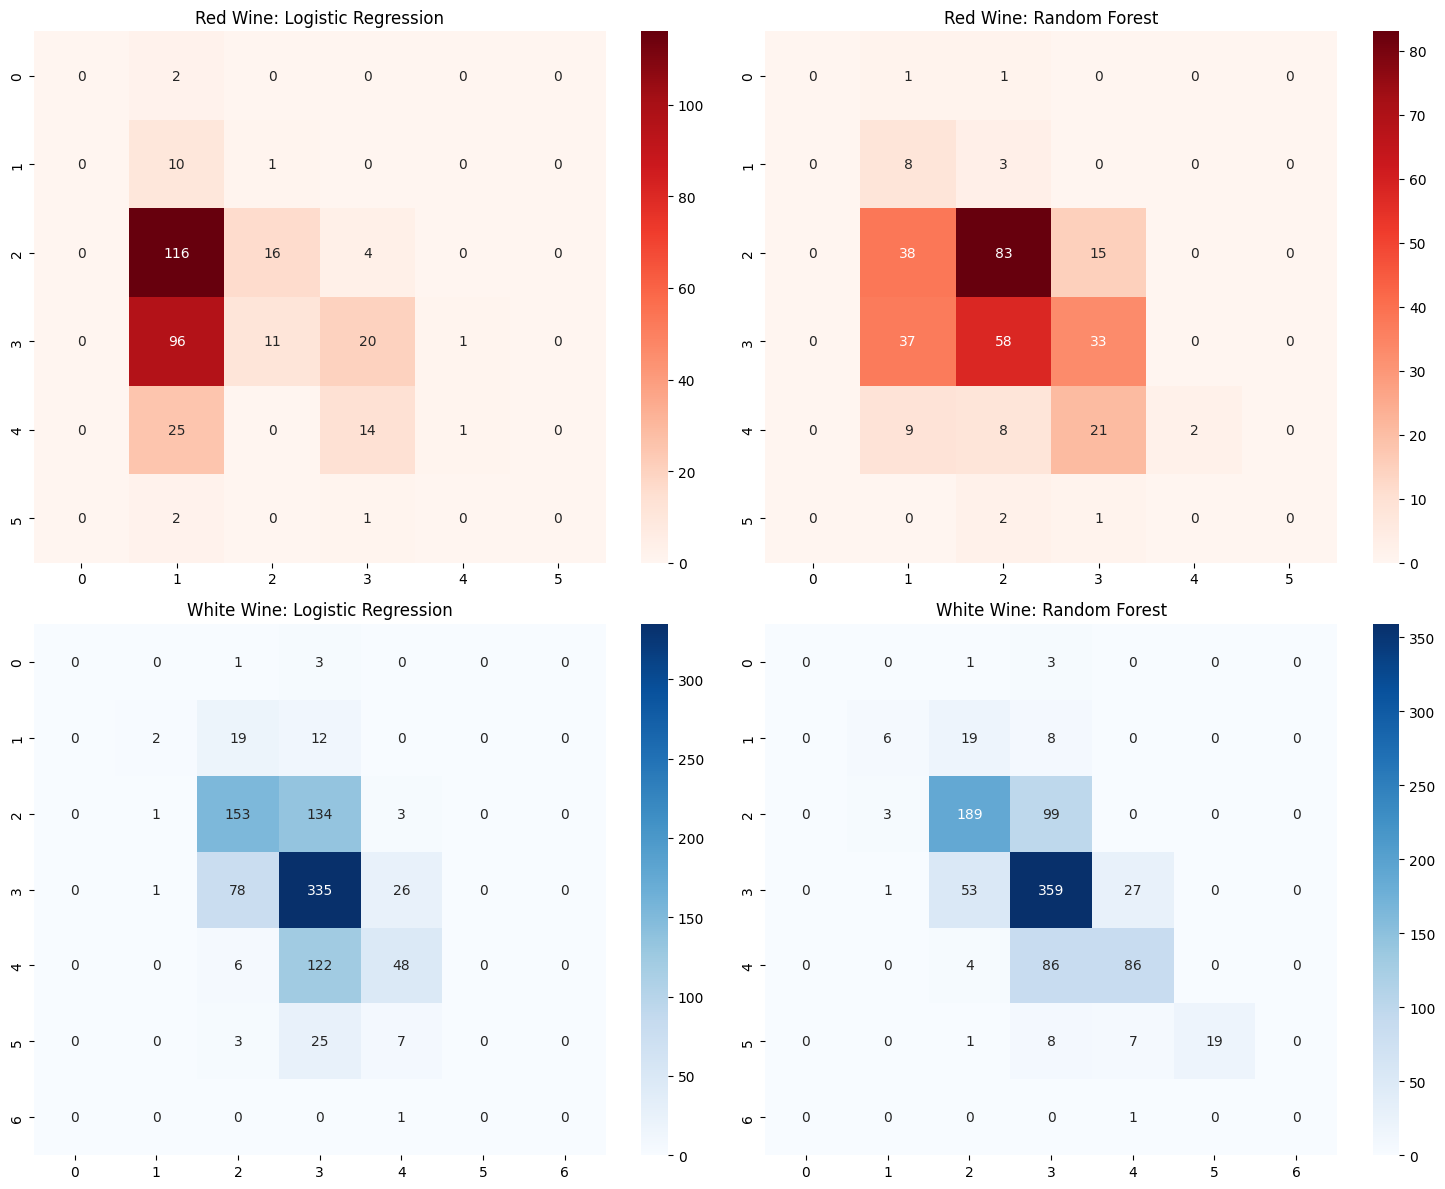

### CLASSIFICATION REPORTS SUMMARY ###

[RED - LOGISTIC REGRESSION]
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.04      0.91      0.08        11
           5       0.57      0.12      0.20       136
           6       0.51      0.16      0.24       128
           7       0.50      0.03      0.05        40
           8       0.00      0.00      0.00         3

    accuracy                           0.15       320
   macro avg       0.27      0.20      0.09       320
weighted avg       0.51      0.15      0.19       320


[RED - RANDOM FOREST]
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.09      0.73      0.15        11
           5       0.54      0.61      0.57       136
           6       0.47      0.26      0.33       128
           7       1.00      0.05      0.10        40
           8       0.00      0.00      

In [11]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# --- STEP 1: Generate all metrics to ensure variables exist ---

# 1. Red Wine: Logistic Regression
y_pred_lr_red = lr_pipeline.predict(X_test_red)
cm_lr_red = confusion_matrix(y_test_red, y_pred_lr_red)
cr_lr_red = classification_report(y_test_red, y_pred_lr_red, zero_division=0)

# 2. Red Wine: Random Forest
y_pred_rf_red = rf_model.predict(X_test_red)
cm_rf_red = confusion_matrix(y_test_red, y_pred_rf_red)
cr_rf_red = classification_report(y_test_red, y_pred_rf_red, zero_division=0)

# 3. White Wine: Logistic Regression
y_pred_lr_white = lr_pipeline.predict(X_test_white)
cm_lr_white = confusion_matrix(y_test_white, y_pred_lr_white)
cr_lr_white = classification_report(y_test_white, y_pred_lr_white, zero_division=0)

# 4. White Wine: Random Forest
y_pred_rf_white = rf_model.predict(X_test_white)
cm_rf_white = confusion_matrix(y_test_white, y_pred_rf_white)
cr_rf_white = classification_report(y_test_white, y_pred_rf_white, zero_division=0)

# --- STEP 2: Create the Comparison Table ---

summary_data = {
    "Dataset": ["Red", "Red", "White", "White"],
    "Model": ["Logistic Regression", "Random Forest", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test_red, y_pred_lr_red),
        accuracy_score(y_test_red, y_pred_rf_red),
        accuracy_score(y_test_white, y_pred_lr_white),
        accuracy_score(y_test_white, y_pred_rf_white)
    ],
    "F1-score (Macro)": [
        f1_score(y_test_red, y_pred_lr_red, average='macro'),
        f1_score(y_test_red, y_pred_rf_red, average='macro'),
        f1_score(y_test_white, y_pred_lr_white, average='macro'),
        f1_score(y_test_white, y_pred_rf_white, average='macro')
    ],
    "Key Observation": [
        "Struggles with rare classes; linear boundaries insufficient.",
        "Significant improvement; best performance for red wine.",
        "Lowest F1-score; heavily biased towards majority classes.",
        "Strongest accuracy but challenged by extreme class 9 imbalance."
    ]
}

comparison_df = pd.DataFrame(summary_data)
display(comparison_df)

# --- STEP 3: Plot the 4 Confusion Matrices ---

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Red Wine
sns.heatmap(cm_lr_red, annot=True, fmt='d', cmap='Reds', ax=axes[0, 0])
axes[0, 0].set_title("Red Wine: Logistic Regression")

sns.heatmap(cm_rf_red, annot=True, fmt='d', cmap='Reds', ax=axes[0, 1])
axes[0, 1].set_title("Red Wine: Random Forest")

# White Wine
sns.heatmap(cm_lr_white, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title("White Wine: Logistic Regression")

sns.heatmap(cm_rf_white, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title("White Wine: Random Forest")

plt.tight_layout()
plt.show()

# --- STEP 4: Print Classification Reports ---

print("### CLASSIFICATION REPORTS SUMMARY ###")
print("\n[RED - LOGISTIC REGRESSION]\n", cr_lr_red)
print("\n[RED - RANDOM FOREST]\n", cr_rf_red)
print("\n[WHITE - LOGISTIC REGRESSION]\n", cr_lr_white)
print("\n[WHITE - RANDOM FOREST]\n", cr_rf_white)

**4–6 lines summarizing: best dataset + best model + reason**

>> Best Dataset: White Wine dataset, as it consistently achieved higher accuracy and F1-scores across both models.

>> Best Model: Random Forest Classifier, which significantly outperformed Logistic Regression for both red and white wines.

>> Reason: Random Forest's ensemble nature and ability to capture complex non-linear relationships allowed it to handle the data's intricacies and class imbalances better than the linear Logistic Regression model.



**Task 7 — Final Conclusion (Comparative Summary)**

**Based on the comparative analysis, below is the comperative summary**

1. The **white wine dataset** proved slightly easier to predict, consistently
yielding higher accuracy and Macro F1-scores with the Random Forest model, despite its more extreme class imbalance.
This suggests that the features within the white wine data might offer better separability for classification.

2. The **Random Forest Classifier** clearly performed better overall compared to Logistic Regression across both datasets.
Its ensemble nature and capacity to model non-linear relationships allowed it to capture more complex patterns and offer improved performance, particularly evident in its higher F1-scores.

3. The **quality classes that were most confusing** were universally the extremely rare ones, such as quality 3, 4, 8, and 9 for both red and white wines.
These classes often registered zero precision, recall, and F1-scores, indicating the models' complete inability to correctly identify them due to insufficient training examples.

4. For a single next improvement, I would suggest implementing **`class_weight="balanced"`** within the Random Forest model.
This approach directly addresses the severe class imbalance, which is the
primary reason for the models' poor performance on rare classes, by penalizing misclassifications of minority classes more heavily during training.